#### 7.3 网络中的网络（NiN）
LeNet、AlexNet、VGG都是通过一些列的卷积层与汇聚层来提取空间机构特征，然后通过全连接层对特征的表征进行处理。使用了全连接层，可能会放弃表征的空间结构。网络中的网络（Net in Net，NiN）提供了一个简单的解决方案：在每个像素的通道上分别使用多层感知机。
##### 7.3.1 NiN块
四维张量：样本、通道、高度、宽度；全连接层的输入和输出通道分别对应样本和特征的二维张量。NiN在每个像素位置（高和宽）应用一个全连接层，如果将权重连接到每个空间位置，开源视其为1×1卷积层，或作为在每个像素位置上毒理作用的全连接层。空间维度中的每个像素视为单个样本，将通道维度视为不同特征。

In [1]:
import torch
from torch import nn
from d2l import torch as d2l

def nin_block(in_channels, out_channels, kernel_size, strides, padding):
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size, stride=strides, padding=padding),
        nn.ReLU(),
        nn.Conv2d(out_channels, out_channels, kernel_size=1), nn.ReLU(),
        nn.Conv2d(out_channels, out_channels, kernel_size=1), nn.ReLU()
    )

##### 7.3.2 NiN模型
NiN使用窗口形状为11×11、5×5、3×3的卷积层，输出通道数与AlexNet中的相同，每个NiN块后有一个最大汇聚层，形状为3×3，步幅为2。NiN取消全连接层，取而代之的是使用一个NiN块，输出通道数等于标签类别数。最后放一个全局平均汇聚层（Global Average Pooling Layer），生成一个对数几率。NiN可以显著减少模型所需参数的数量，但可能会增加训练模型的时间。

In [4]:
net = nn.Sequential(
    nin_block(1, 96, kernel_size=11, strides=4, padding=0),
    nn.MaxPool2d(3, stride=2),
    nin_block(96, 256, kernel_size=5, strides=1, padding=2),
    nn.MaxPool2d(3, stride=2),
    nin_block(256, 384, kernel_size=3, strides=1, padding=1),
    nn.MaxPool2d(3, stride=2),
    nn.Dropout(0.5),
    nin_block(384, 10, kernel_size=3, strides=1, padding=1),
    nn.AdaptiveAvgPool2d((1, 1)),
    nn.Flatten()    # 将四维输出转成二维输出，形状为（批量大小,10）
)

In [9]:
X = torch.rand(size=(1, 1, 224, 224))
for layer in net:
    X = layer(X)
    print(layer.__class__.__name__, 'output shape:\t', X.shape)

Sequential output shape:	 torch.Size([1, 96, 54, 54])
MaxPool2d output shape:	 torch.Size([1, 96, 26, 26])
Sequential output shape:	 torch.Size([1, 256, 26, 26])
MaxPool2d output shape:	 torch.Size([1, 256, 12, 12])
Sequential output shape:	 torch.Size([1, 384, 12, 12])
MaxPool2d output shape:	 torch.Size([1, 384, 5, 5])
Dropout output shape:	 torch.Size([1, 384, 5, 5])
Sequential output shape:	 torch.Size([1, 10, 5, 5])
AdaptiveAvgPool2d output shape:	 torch.Size([1, 10, 1, 1])
Flatten output shape:	 torch.Size([1, 10])


##### 7.3.3 训练模型

loss 0.358, train acc 0.867, test acc 0.851
1156.3 examples/sec on cuda:0


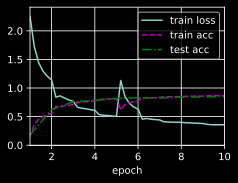

In [10]:
lr, num_epochs, batch_size = 0.1, 10, 128
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size, resize=224)
d2l.train_ch6(net, train_iter, test_iter, num_epochs, lr, torch.device('cuda:0'))

loss 0.328, train acc 0.881, test acc 0.883
841.9 examples/sec on cuda:0


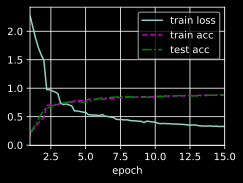

In [12]:
lr, num_epochs, batch_size = 0.05, 15, 128
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size, resize=224)
d2l.train_ch6(net, train_iter, test_iter, num_epochs, lr, torch.device('cuda:0'))

#### 7.4 含并行连接的网络（GoogLeNet）
GoogLeNet吸收了NiN中串联网络的思想，并在此基础上做出改进，解决了卷积核大小适配的问题。
##### 7.4.1 Inception块
GoogLeNet中基本的卷积块为Inception块，由4条并行路径组成，前3条路径使用窗口为1×1、3×3、5×5的卷积层，从不同空间大小中提取信息。中间的2条路径在输入上执行1×1卷积，以减少通道数，降低模型复杂度。第4条路径使用3×3最大汇聚层，然后使用1×1卷积层来改变通道数。这4条路径都是用合适的填充以使输入与输出的高度和宽度一致，最后将每条路径的输出在通道维度上合并，构成Inception块输出。

In [1]:
from torch.nn import functional as F

class Inception(nn.Module):
    # c1~c4是每条路径的输出通道
    def __init__(self, in_channels, c1, c2, c3, c4, **kwargs):
        super(Inception, self).__init__(**kwargs)
        # 路径1：单1×1网络


AttributeError: module 'numpy' has no attribute 'ndarray'